In [1]:
from datetime import datetime
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, IntSlider
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from av_mat_generation.CI_based.window import Window, load_data, COUNTRIES
from matplotlib import pyplot as plt

cmap = LinearSegmentedColormap.from_list('black_white_black', ['black', 'white', 'black'], N=256)

start_date = datetime(2022, 1, 1, 0, 0)
end_date = datetime(2022, 12, 31, 23, 59, 59)

In [2]:
# data preparation:
_dfs = load_data()

# Ranking analysis

In [45]:
# Converting dictionary of dataframe into a single dataframe
_tmp = pd.concat(
    [
        _dfs[country][["datetime", "CI_direct"]]
        .set_index("datetime")
        .rename(columns={"CI_direct": country})
        for country in _dfs.keys()
    ],
    axis=1,
    sort=False,
)

# Ranking each row based on the value
_tmp = _tmp.rank(ascending=True, method="first", axis=1)

# Converting rank dataframe into tally table with rank as the index
_tmp = pd.concat(
    [
        _tmp[col]
        .value_counts()
        .reset_index()
        .rename(columns={col: "rank", "count": col})
        .set_index("rank")
        for col in _tmp.columns
    ],
    axis=1,
    sort=True,
).fillna(0.0)

In [46]:
# Ordering countries based on the count value for each rank
order_col = []
for row in _tmp.iterrows():
       # Sorting the values only when they are non-zero 
       order_col += row[1][row[1] != 0].drop(index=order_col, errors='ignore').sort_values(ascending=False).index.to_list()

In [48]:
_tmp

,Germany,Ireland,Great Britain,France,Sweden,Finland,Belgium,Brazil,Denmark,Estonia,Spain,Hungary,Singapore,Italy,Japan,South Africa,Uruguay,Croatia
rank,,,,,,,,,,,,,,,,,,
1.0,0.0,0.0,0.0,0.0,3443.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5317.0,0.0
2.0,0.0,0.0,9.0,1205.0,5310.0,221.0,2.0,1041.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,947.0,0.0
3.0,0.0,1.0,154.0,2720.0,7.0,1914.0,323.0,3000.0,336.0,0.0,35.0,0.0,0.0,0.0,0.0,0.0,270.0,0.0
4.0,0.0,28.0,386.0,2906.0,0.0,772.0,890.0,2152.0,844.0,0.0,264.0,0.0,0.0,0.0,0.0,0.0,518.0,0.0
5.0,0.0,77.0,585.0,1400.0,0.0,1341.0,1571.0,1506.0,1255.0,2.0,624.0,0.0,0.0,0.0,0.0,0.0,399.0,0.0
6.0,2.0,182.0,742.0,480.0,0.0,1337.0,1900.0,746.0,2016.0,11.0,936.0,0.0,0.0,0.0,0.0,0.0,400.0,8.0
7.0,17.0,312.0,1130.0,42.0,0.0,1161.0,2421.0,259.0,1719.0,120.0,1301.0,6.0,0.0,0.0,0.0,0.0,249.0,23.0
8.0,32.0,463.0,1985.0,7.0,0.0,1037.0,1257.0,45.0,1188.0,425.0,1864.0,176.0,0.0,6.0,3.0,0.0,207.0,65.0
9.0,66.0,842.0,2444.0,0.0,0.0,632.0,328.0,11.0,790.0,565.0,2136.0,482.0,0.0,63.0,13.0,0.0,212.0,176.0


<Axes: title={'center': 'Rank at hourly level'}, ylabel='rank'>

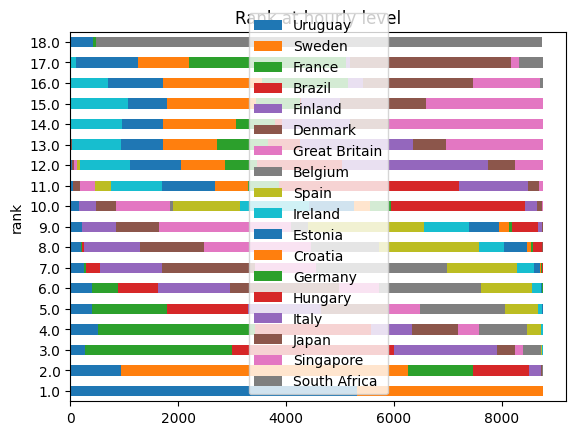

In [47]:
_tmp.loc[:,order_col].plot(kind='barh', stacked=True, title="Rank at hourly level")

# Cross correlation analysis

In [9]:
god_df = pd.concat(
    [
        _dfs[country][["datetime", "CI_direct"]]
        .set_index("datetime")
        .rename(columns={"CI_direct": country})
        for country in _dfs.keys()
    ],
    axis=1,
    sort=False,
)[
    ["Belgium",
        "Germany",
        "France",
        "Spain",
        "Italy",
        "Great Britain",
        "Ireland",
        "Denmark",
        "Sweden",
        "Finland",
        "Estonia",
        "Hungary",
        "Croatia",
        "Uruguay",
        "Brazil",
        "Singapore",
        "Japan",
        "South Africa",    
    ]
]

In [10]:
# Interactive function for heatmap with a sliding window
def interactive_heatmap(start_row=0, window_size=100):
    # Ensure the window size does not exceed the DataFrame length
    end_row = start_row + window_size
    end_row = min(end_row, len(god_df))
    
    # Calculate correlation on the sliding window
    corr_matrix = god_df.iloc[start_row:end_row].corr()

    # Plot heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(corr_matrix, annot=True, cmap=cmap, vmin=-1.0, vmax=1.0)
    plt.title(f'Correlation Matrix from Row {start_row} to {end_row}')
    plt.show()

# Create slider widgets
start_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(god_df) - 1,
    step=1,
    description='Start Row:',
    continuous_update=False
)

window_slider = widgets.IntSlider(
    value=100,
    min=10,
    max=len(god_df),
    step=10,
    description='Window Size:',
    continuous_update=False
)

# Display interactive widget
interact(interactive_heatmap, start_row=start_slider, window_size=window_slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Start Row:', max=8759), IntSlid…

<function __main__.interactive_heatmap(start_row=0, window_size=100)>

## Diffent Frequency wise cross correlation value

In [11]:
def monthly_heatmap(month):
    # Filter the DataFrame for the selected month
    df_god_tmp = god_df.loc[god_df.index.month == month]
    
    correlation_matrix = df_god_tmp.corr()
    
    # Plot the heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(correlation_matrix, annot=True, vmin=-1.0, vmax=1.0, cmap=cmap, center=0)
    plt.title(f'Correlation Matrix for Month {month}')
    plt.show()

# Create a slider for month selection
month_slider = IntSlider(value=1, min=1, max=12, step=1, description='Month:', continuous_update=False)

# Use interact to create an interactive widget
interact(monthly_heatmap, month=month_slider)

interactive(children=(IntSlider(value=1, continuous_update=False, description='Month:', max=12, min=1), Output…

<function __main__.monthly_heatmap(month)>

In [12]:
def quarter_heatmap(quarter):
    # Filter the DataFrame for the selected month
    df_god_tmp = god_df.loc[god_df.index.quarter == quarter]
    
    correlation_matrix = df_god_tmp.corr()
    
    # Plot the heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(correlation_matrix, annot=True, vmin=-1.0, vmax=1.0, cmap=cmap, center=0)
    plt.title(f'Correlation Matrix for quarter {quarter}')
    plt.show()

# Create a slider for month selection
quarter_slider = IntSlider(value=1, min=1, max=4, step=1, description='quarter:', continuous_update=True)

# Use interact to create an interactive widget
interact(quarter_heatmap, quarter=quarter_slider)

interactive(children=(IntSlider(value=1, description='quarter:', max=4, min=1), Output()), _dom_classes=('widg…

<function __main__.quarter_heatmap(quarter)>

In [13]:
def week_heatmap(week):
    # Filter the DataFrame for the selected month
    df_god_tmp = god_df.loc[god_df.index.isocalendar().week == week]
    
    # Calculate the correlation matrix
    correlation_matrix = df_god_tmp.corr()
    
    # Plot the heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(correlation_matrix, annot=True, vmin=-1.0, vmax=1.0, cmap=cmap, center=0)
    plt.title(f'Correlation Matrix for week {week}')
    plt.show()

# Create a slider for month selection
weekly_slider = IntSlider(value=1, min=1, max=52, step=1, description='Week:', continuous_update=True)

# Use interact to create an interactive widget
interact(week_heatmap, week=weekly_slider)

interactive(children=(IntSlider(value=1, description='Week:', max=52, min=1), Output()), _dom_classes=('widget…

<function __main__.week_heatmap(week)>

<Axes: >

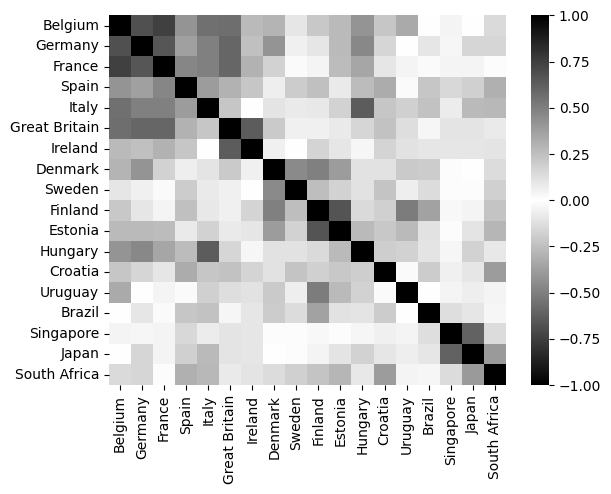

In [44]:
sns.heatmap(god_df.corr(), cmap=cmap, vmin=-1, vmax=1.0)

# Country analysis with movable avail_mat

In [19]:
BELGIUM = "Belgium"
GERMANY = "Germany"
FRANCE = "France"
SPAIN = "Spain"
ITALY = "Italy"
GREAT_BRITAIN = "Great Britain"
IRELAND = "Ireland"
DENMARK = "Denmark"
SWEDEN = "Sweden"
FINLAND = "Finland"
ESTONIA = "Estonia"
HUNGARY = "Hungary"
CROATIA = "Croatia"
URUGUAY = "Uruguay"
BRAZIL = "Brazil"
SINGAPORE = "Singapore"
JAPAN = "Japan"
SOUTH_AFRICA = "South Africa"

In [14]:
import numpy as np

In [35]:
power = 300 / 1000  # in kiloWatts
round_duration = 1  # in hours: this is duration of a FL training round
n_rows = 100
all_countries = [BELGIUM, FRANCE, GERMANY, SPAIN, ITALY, GREAT_BRITAIN, IRELAND, DENMARK, SWEDEN, FINLAND, ESTONIA, HUNGARY, CROATIA, URUGUAY, BRAZIL, SINGAPORE, JAPAN, SOUTH_AFRICA]


ghg_god_df = god_df * power * round_duration / 1000

In [40]:
from ipywidgets import Button, Box

Box(children=(Checkbox(value=True, description='Belgium'), Checkbox(value=True, description='France'), Checkbo…

Button(description='Go', style=ButtonStyle())

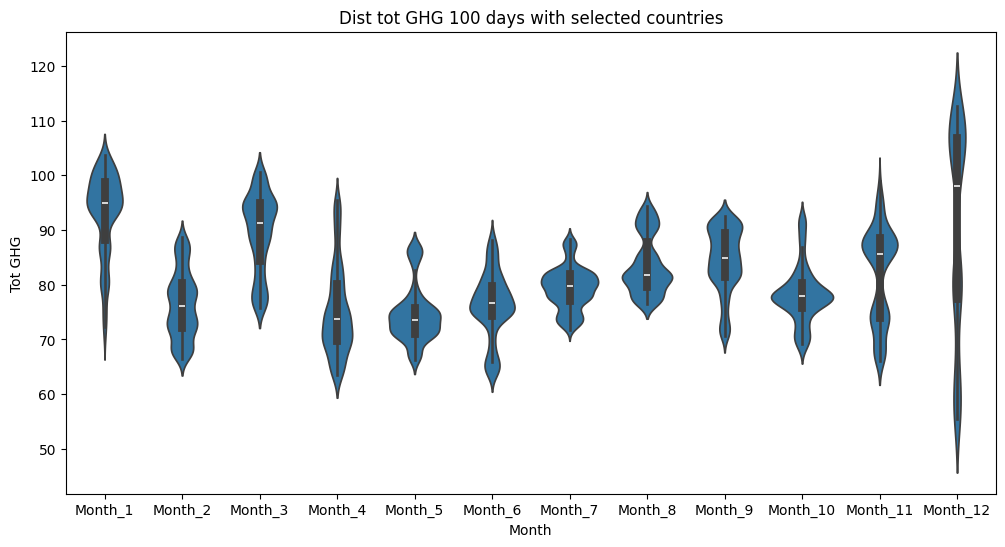

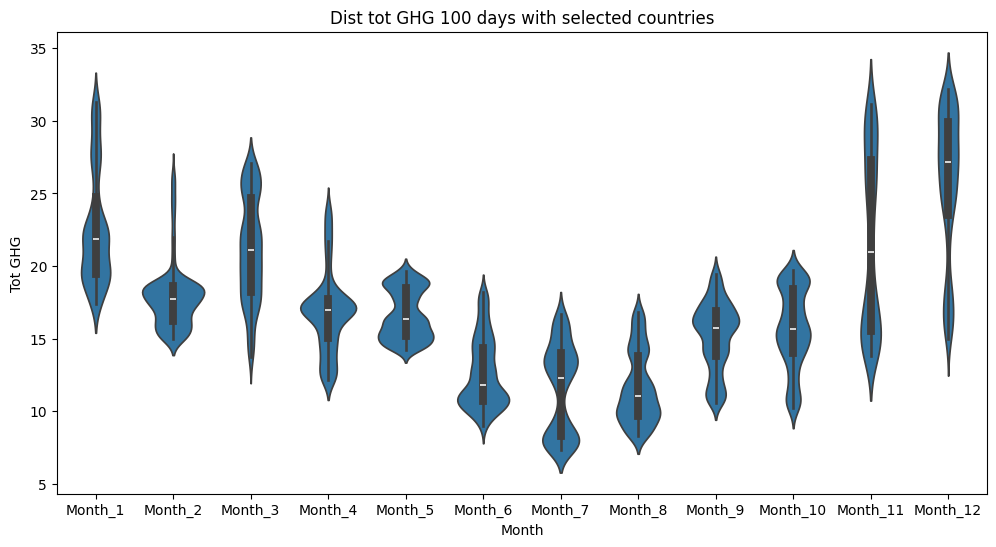

In [42]:
# Create a list of Checkboxes for each country
checkboxes = [widgets.Checkbox(value=True, description=country) for country in all_countries]

# Create a VBox container for the checkboxes
checkbox_box = Box(children=checkboxes, layout=widgets.Layout(display='flex', flex_flow='row wrap', justify_content='flex-start'))

# Function to plot based on selected countries
def plot_violin(button):
    # Get selected countries from checkboxes
    countries = [checkbox.description for checkbox in checkboxes if checkbox.value]
    
    if not countries:
        print("Please select at least one country!")
        return
    
    try:
        _df = ghg_god_df[countries]
    except KeyError as e:
        print(f"Error: The following countries were not found in the dataset: {e}")
        return
    
    val = list()
    for _ in range(1000):
        _val = list()
        for month in range(1, 13):
            _tmp = _df[_df.index.month == month]  # Correct indexing for month
            if len(_tmp) > 0:
                start_idx = np.random.randint(0, len(_tmp) - 100 + 1)  # Replace 100 with n_rows if needed
                _val.append(np.sum(_tmp.iloc[start_idx:start_idx + 100].values))  # Replace 100 with n_rows if needed
            else:
                _val.append(0)  # If no data for this month, append zero or handle appropriately
        val.append(_val)
    val = np.array(val)
    df = pd.DataFrame(val, columns=[f"Month_{i+1}" for i in range(12)])

    # Melt the DataFrame for Seaborn's boxplot format
    df_melted = df.melt(var_name="Month", value_name="Value")

    # Plot the violin plot
    plt.figure(figsize=(12, 6))
    sns.violinplot(x="Month", y="Value", data=df_melted, inner="box")
    plt.title(f"Dist tot GHG 100 days with {countries} countries")
    plt.xlabel("Month")
    plt.ylabel("Tot GHG")
    plt.show()

# Create a button widget for "Go"
go_button = Button(description="Go")

# Set the button action to call plot_violin function when clicked
go_button.on_click(plot_violin)

# Display the widgets
display(checkbox_box, go_button)

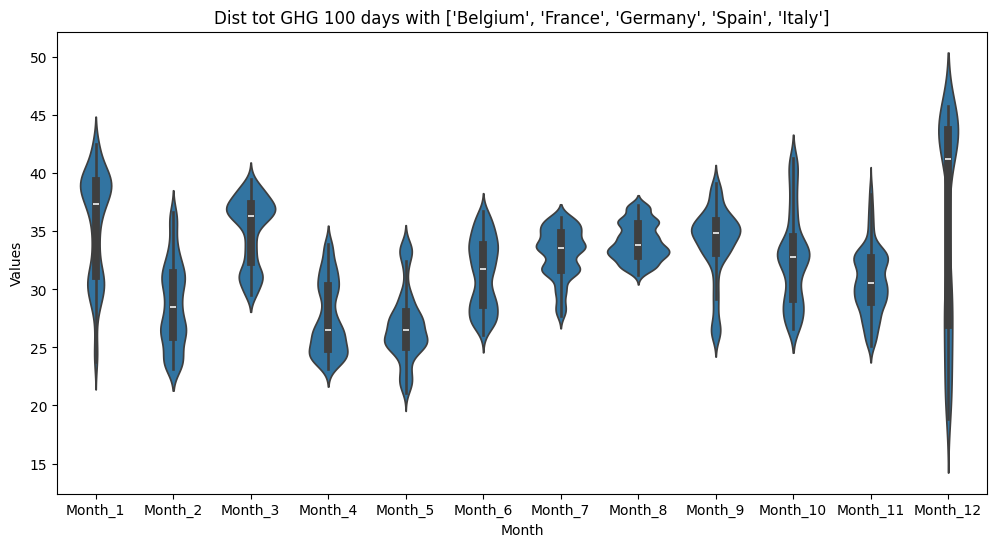

In [20]:
countries = [BELGIUM, FRANCE, GERMANY, SPAIN, ITALY]
val = list()
_df = ghg_god_df[countries]
for _ in range(1000):
    _val = list()
    for month in range(1,13):
        _tmp = _df.loc[_df.index.month == month]
        start_idx = np.random.randint(0, len(_tmp) - n_rows + 1)
        _val.append(np.sum(_tmp.iloc[start_idx:start_idx + n_rows].values))
    val.append(_val)
val = np.array(val)
df = pd.DataFrame(val, columns=[f"Month_{i+1}" for i in range(12)])

# Melt the DataFrame to have 'Month' and 'Value' columns for Seaborn's boxplot format
df_melted = df.melt(var_name="Month", value_name="Value")

# Plot the box plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Month", y="Value", data=df_melted, inner="box")
plt.title(f"Dist tot GHG 100 days with {countries}")
plt.xlabel("Month")
plt.ylabel("Tot GHG")
plt.show()

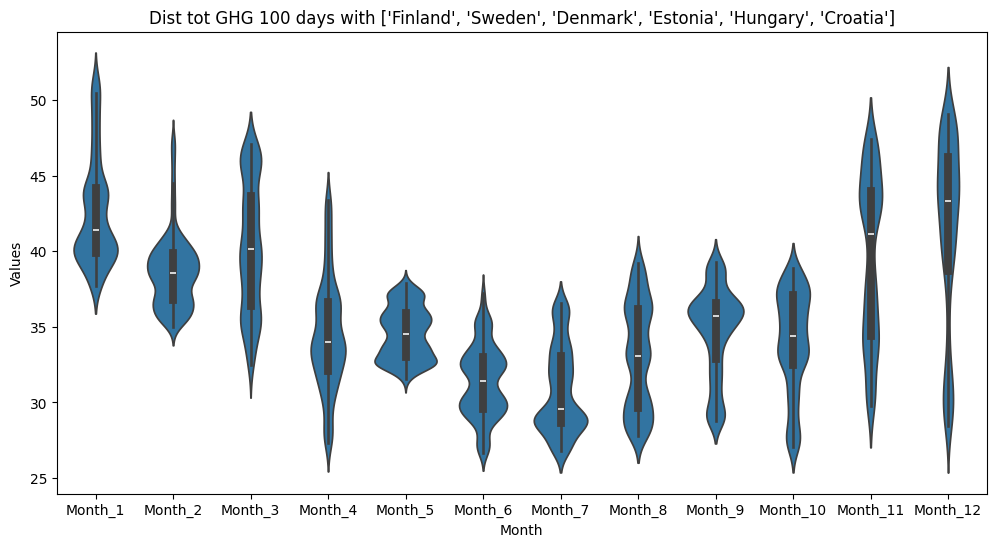

In [21]:
countries = [FINLAND, SWEDEN, DENMARK, ESTONIA, HUNGARY, CROATIA]
val = list()
_df = ghg_god_df[countries]
for _ in range(1000):
    _val = list()
    for month in range(1,13):
        _tmp = _df.loc[_df.index.month == month]
        start_idx = np.random.randint(0, len(_tmp) - n_rows + 1)
        _val.append(np.sum(_tmp.iloc[start_idx:start_idx + n_rows].values))
    val.append(_val)
val = np.array(val)
df = pd.DataFrame(val, columns=[f"Month_{i+1}" for i in range(12)])

# Melt the DataFrame to have 'Month' and 'Value' columns for Seaborn's boxplot format
df_melted = df.melt(var_name="Month", value_name="Value")

# Plot the box plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Month", y="Value", data=df_melted, inner="box")
plt.title(f"Dist tot GHG 100 days with {countries}")
plt.xlabel("Month")
plt.ylabel("Tot GHG")
plt.show()

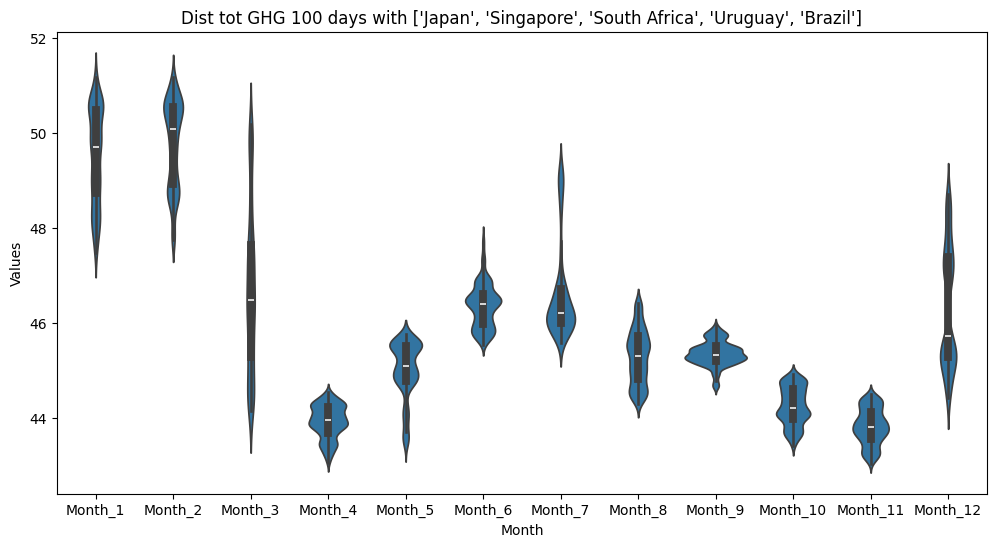

In [24]:
countries = [JAPAN, SINGAPORE, SOUTH_AFRICA, URUGUAY, BRAZIL]
val = list()
_df = ghg_god_df[countries]
for _ in range(1000):
    _val = list()
    for month in range(1,13):
        _tmp = _df.loc[_df.index.month == month]
        start_idx = np.random.randint(0, len(_tmp) - n_rows + 1)
        _val.append(np.sum(_tmp.iloc[start_idx:start_idx + n_rows].values))
    val.append(_val)
val = np.array(val)
df = pd.DataFrame(val, columns=[f"Month_{i+1}" for i in range(12)])

# Melt the DataFrame to have 'Month' and 'Value' columns for Seaborn's boxplot format
df_melted = df.melt(var_name="Month", value_name="Value")

# Plot the box plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Month", y="Value", data=df_melted, inner="box")
plt.title(f"Dist tot GHG 100 days with {countries}")
plt.xlabel("Month")
plt.ylabel("Tot GHG")
plt.show()

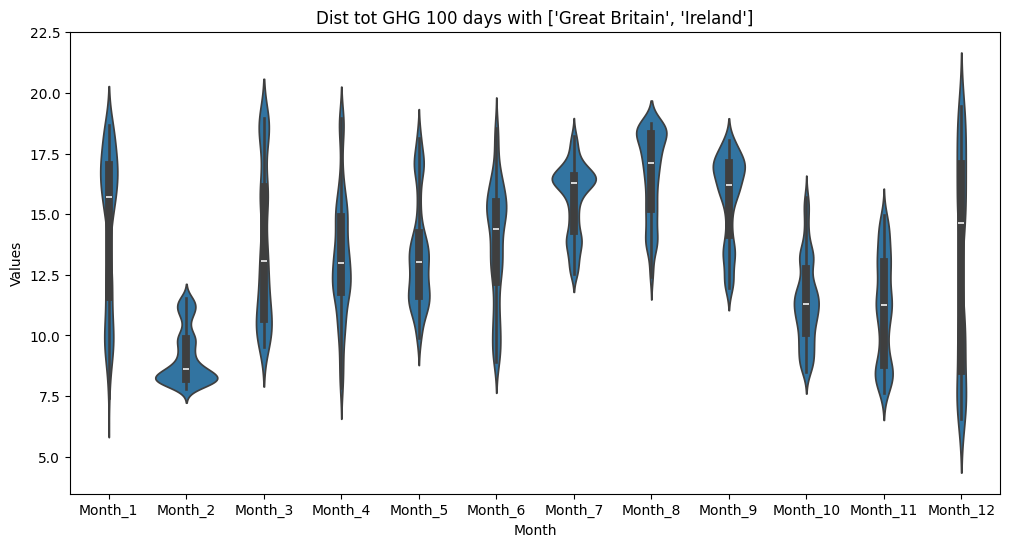

In [23]:
countries = [GREAT_BRITAIN, IRELAND]
val = list()
_df = ghg_god_df[countries]
for _ in range(1000):
    _val = list()
    for month in range(1,13):
        _tmp = _df.loc[_df.index.month == month]
        start_idx = np.random.randint(0, len(_tmp) - n_rows + 1)
        _val.append(np.sum(_tmp.iloc[start_idx:start_idx + n_rows].values))
    val.append(_val)
val = np.array(val)
df = pd.DataFrame(val, columns=[f"Month_{i+1}" for i in range(12)])

# Melt the DataFrame to have 'Month' and 'Value' columns for Seaborn's boxplot format
df_melted = df.melt(var_name="Month", value_name="Value")

# Plot the box plot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Month", y="Value", data=df_melted, inner="box")
plt.title(f"Dist tot GHG 100 days with {countries}")
plt.xlabel("Month")
plt.ylabel("Tot GHG")
plt.show()